In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
df = pd.read_csv("imdb_top_1000.csv")
df.head()


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [15]:
# Select required columns
df = df[['Title', 'Genre', 'Rating', 'Year']]

# Rename for clarity
df.columns = ['movie_title', 'genre', 'imdb_rating', 'year']

# Handle missing values
df.dropna(inplace=True)

# Convert rating to numeric
df['imdb_rating'] = pd.to_numeric(df['imdb_rating'], errors='coerce')


In [16]:
mean_rating = df['imdb_rating'].mean()
median_rating = df['imdb_rating'].median()
mode_rating = df['imdb_rating'].mode()[0]

mean_rating, median_rating, mode_rating


(np.float64(6.723199999999999), 6.8, np.float64(7.1))

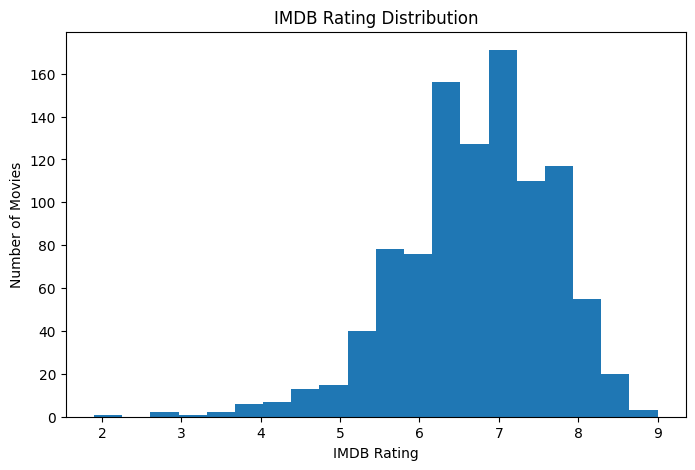

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['imdb_rating'], bins=20)
plt.xlabel("IMDB Rating")
plt.ylabel("Number of Movies")
plt.title("IMDB Rating Distribution")
plt.show()


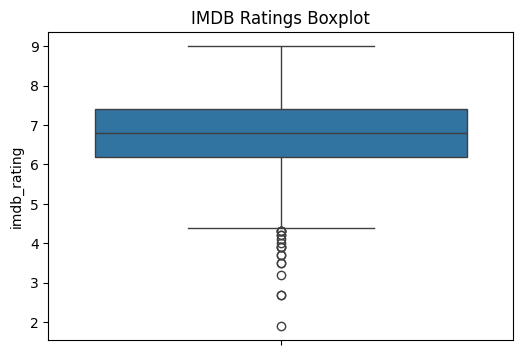

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['imdb_rating'])
plt.title("IMDB Ratings Boxplot")
plt.show()


In [19]:
top_movies = df.sort_values(by='imdb_rating', ascending=False).head(10)
top_movies


,movie_title,genre,imdb_rating,year
54,The Dark Knight,"Action,Crime,Drama",9.0,2008
80,Inception,"Action,Adventure,Sci-Fi",8.8,2010
117,Dangal,"Action,Biography,Drama",8.8,2016
36,Interstellar,"Adventure,Drama,Sci-Fi",8.6,2014
249,The Intouchables,"Biography,Comedy,Drama",8.6,2011
96,Kimi no na wa,"Animation,Drama,Fantasy",8.6,2016
64,The Prestige,"Drama,Mystery,Sci-Fi",8.5,2006
99,The Departed,"Crime,Drama,Thriller",8.5,2006
476,The Lives of Others,"Drama,Thriller",8.5,2006
124,The Dark Knight Rises,"Action,Thriller",8.5,2012


In [20]:
df['genre'] = df['genre'].str.split(', ')
df_exploded = df.explode('genre')


In [21]:
genre_ratings = df_exploded.groupby('genre')['imdb_rating'].mean().sort_values(ascending=False)
genre_ratings.head(10)


,imdb_rating
genre,
"Animation,Drama,Fantasy",8.60
"Drama,Family,Music",8.50
"Drama,Western",8.40
"Animation,Drama,Romance",8.40
"Adventure,Drama,Sci-Fi",8.30
"Adventure,Drama,War",8.30
"Drama,Fantasy,War",8.20
"Drama,Mystery,War",8.20
"Biography,Comedy,Crime",8.20


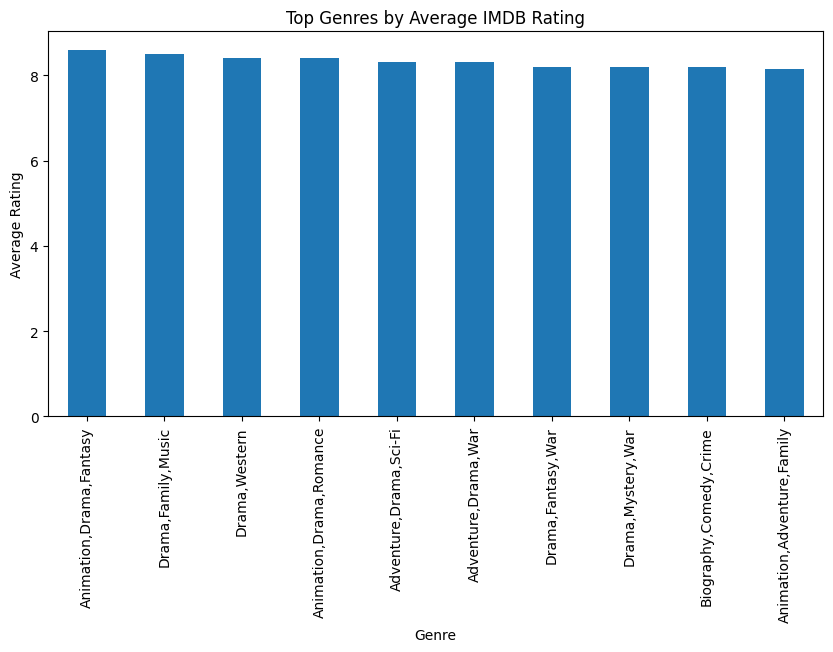

In [22]:
plt.figure(figsize=(10,5))
genre_ratings.head(10).plot(kind='bar')
plt.title("Top Genres by Average IMDB Rating")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.show()


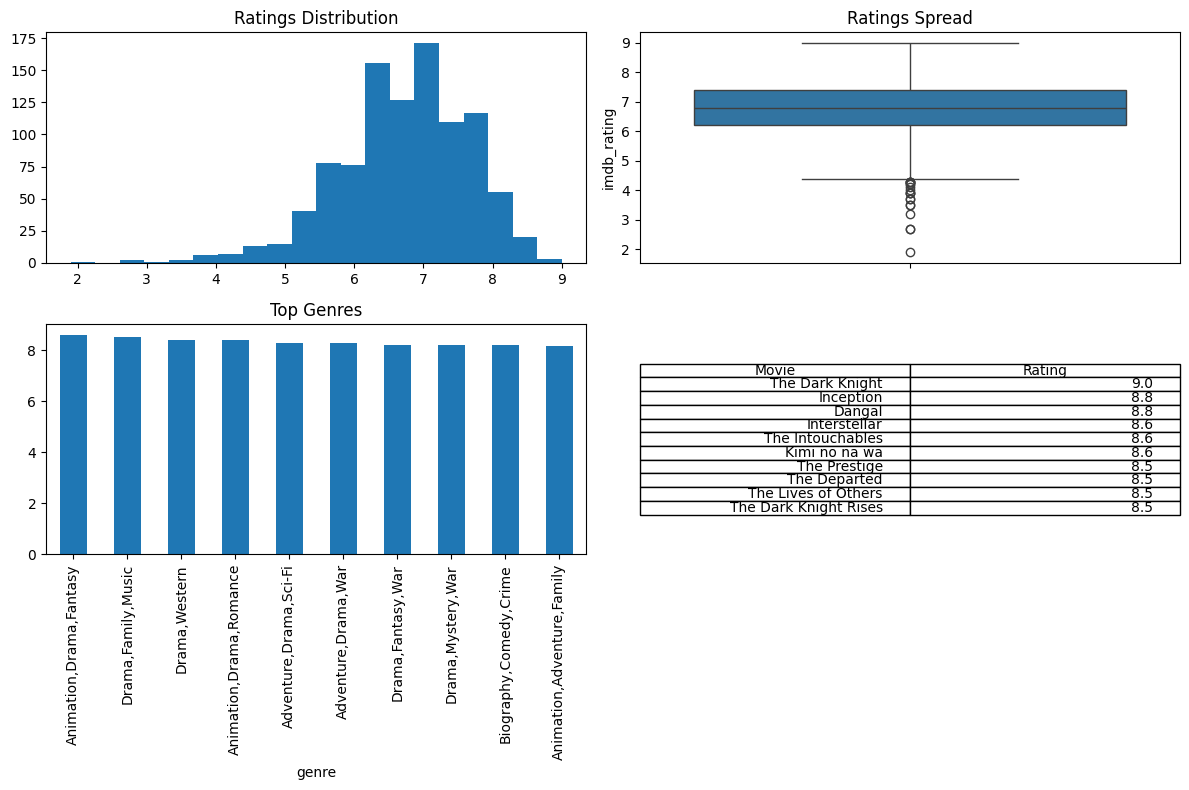

In [23]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.hist(df['imdb_rating'], bins=20)
plt.title("Ratings Distribution")

plt.subplot(2,2,2)
sns.boxplot(y=df['imdb_rating'])
plt.title("Ratings Spread")

plt.subplot(2,2,3)
genre_ratings.head(10).plot(kind='bar')
plt.title("Top Genres")

plt.subplot(2,2,4)
plt.axis('off')
plt.table(
    cellText=top_movies[['movie_title','imdb_rating']].values,
    colLabels=['Movie','Rating'],
    loc='center'
)

plt.tight_layout()
plt.show()
